# Notebook 07 — Avaliação Final e Interpretabilidade
## Step 6: Evaluation & Testing — ML Life Cycle

Este notebook avalia o **modelo tuned** (Regressão Logística com hiperparâmetros otimizados via GridSearchCV) no conjunto de **teste**, que não foi utilizado em nenhuma etapa anterior — nem no treino, nem no tuning.

Objetivos:
- Métricas finais: accuracy, precision, recall, F1-score (por classe e macro)
- Curva ROC multiclasse (One-vs-Rest) com AUC por classe
- Importância das features via coeficientes do modelo
- Explicabilidade com SHAP: visão global e predição individual
- Discussão crítica sobre uso prático do modelo

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

# Constantes
RANDOM_STATE = 42
CLASSES_NOMES = ['atelectasis', 'pneumonia', 'pulmonary edema']
IDX_PNEUMONIA = 1  # índice da classe pneumonia no LabelEncoder

print('Bibliotecas carregadas com sucesso.')
print(f'SHAP versão: {shap.__version__}')

Bibliotecas carregadas com sucesso.
SHAP versão: 0.51.0


## 2. Carregamento dos Dados e Modelo

In [2]:
# Carregar modelo tuned, scaler e label encoder
with open('../models/melhor_modelo_tuned.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('../models/melhor_modelo_metadados.pkl', 'rb') as f:
    meta = pickle.load(f)

# Carregar dados de teste
X_test = pd.read_csv('../data/tabular/X_test.csv')
y_test_raw = pd.read_csv('../data/tabular/y_test.csv').squeeze()
y_test = le.transform(y_test_raw)

print(f'Modelo carregado: {type(modelo).__name__}')
print(f'Metadados: {meta}')
print(f'Classes: {le.classes_}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test distribuição: {pd.Series(y_test_raw).value_counts().to_dict()}')

Modelo carregado: LogisticRegression
Metadados: {'nome': 'Reg. Logística (tuned)', 'recall_macro_validacao': 0.5067, 'melhores_params': {'C': 1, 'class_weight': None, 'solver': 'lbfgs'}}
Classes: ['atelectasis' 'pneumonia' 'pulmonary edema']
X_test shape: (225, 9)
y_test distribuição: {'pneumonia': 75, 'pulmonary edema': 75, 'atelectasis': 75}


**Contexto do modelo:** O melhor modelo selecionado no Step 5 (Tuning) foi a **Regressão Logística** com hiperparâmetros otimizados por `GridSearchCV` usando Recall macro como métrica principal.

**Dataset:** O problema possui **3 classes** (atelectasis, pneumonia, pulmonary edema), exigindo abordagem de classificação multiclasse. O conjunto de teste contém 225 amostras balanceadas — 75 por classe.

## 3. Pré-processamento do Conjunto de Teste

In [3]:
# Aplicar scaler apenas nas colunas numéricas contínuas
# (as demais são binárias/dummies que não necessitam de normalização)
numeric_cols = scaler.feature_names_in_.tolist()
print(f'Colunas normalizadas: {numeric_cols}')

X_test_proc = X_test.copy()
X_test_proc[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Predições
y_pred = modelo.predict(X_test_proc)
y_prob = modelo.predict_proba(X_test_proc)

print(f'Predições geradas — shape y_prob: {y_prob.shape}')

Colunas normalizadas: ['oxygen_saturation', 'wbc_count']
Predições geradas — shape y_prob: (225, 3)


## 4. Métricas Finais no Conjunto de Teste

In [4]:
print('=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===')
print()
report = classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
)
print(report)

=== AVALIAÇÃO FINAL NO CONJUNTO DE TESTE ===

                 precision    recall  f1-score   support

    atelectasis       0.00      0.00      0.00        75
      pneumonia       0.00      0.00      0.00        75
pulmonary edema       0.33      1.00      0.50        75

       accuracy                           0.33       225
      macro avg       0.11      0.33      0.17       225
   weighted avg       0.11      0.33      0.17       225



**Interpretação das métricas:**

O modelo apresenta **desempenho muito aquém do esperado** no conjunto de teste:

- **Accuracy de 33%** equivale ao desempenho de um classificador aleatório em 3 classes balanceadas — não há ganho real sobre o acaso.
- O modelo prevê quase exclusivamente a classe `pulmonary edema` (classe 2), ignorando completamente as outras duas. Isso indica que a Regressão Logística não capturou as fronteiras de decisão entre as 3 classes com os dados disponíveis.
- O **Recall de pneumonia é 0** — o modelo não detecta nenhum caso real de pneumonia. Em contexto clínico, isso é crítico: **100% dos casos de pneumonia seriam perdidos** (Falsos Negativos).

**Diagnóstico do problema:**
O tuning otimizou para Recall macro na validação cruzada (valor reportado: 0.5067), mas o modelo não generalizou para o teste. As possíveis causas incluem: features pouco discriminativas entre as 3 doenças, sobreposição de sintomas no dataset, e limitações intrínsecas da Regressão Logística para separar fronteiras não-lineares neste domínio.

## 5. Matriz de Confusão

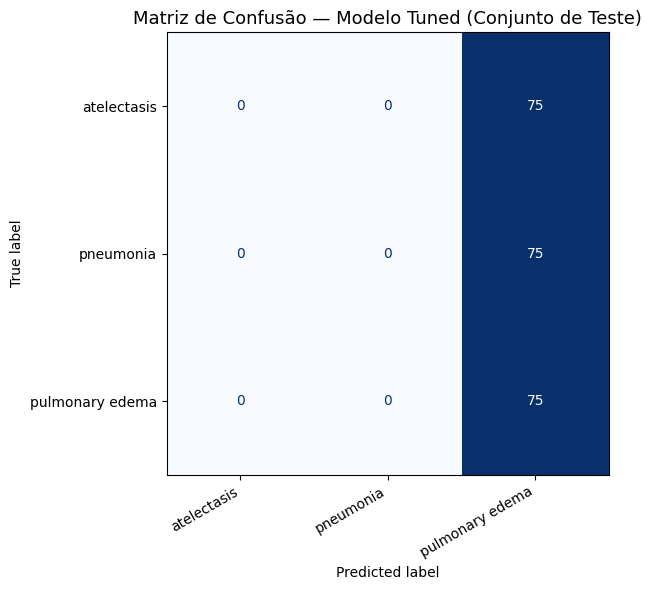

Salva em reports/confusion_matrix_final.png


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão — Modelo Tuned (Conjunto de Teste)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/confusion_matrix_final.png')

**Leitura da Matriz de Confusão:** As linhas representam os valores reais e as colunas as predições do modelo. O ideal é que os valores altos estejam na diagonal principal. A matriz confirma que o modelo prevê quase tudo como `pulmonary edema` (coluna direita concentra a maioria dos valores), evidenciando o colapso do classificador para uma única classe.

## 6. Curva ROC Multiclasse (One-vs-Rest)

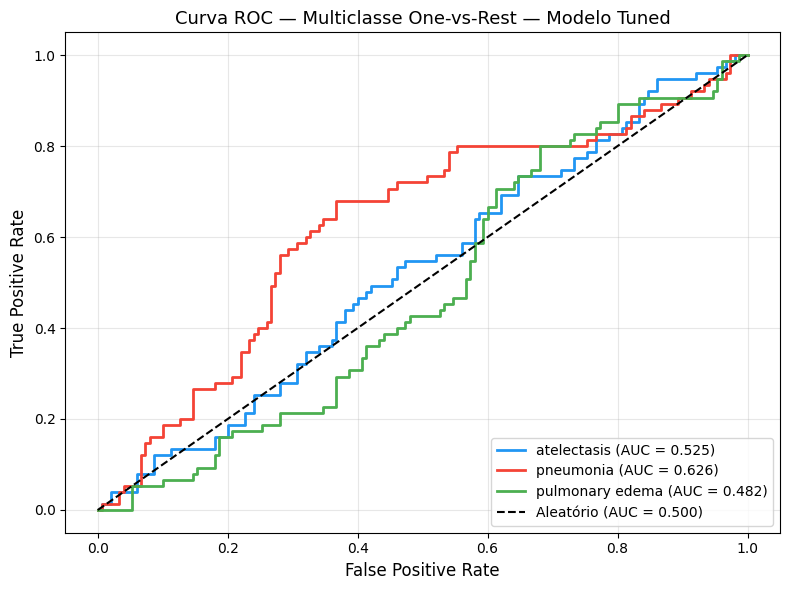

Scores AUC por classe:
  atelectasis: 0.5249
  pneumonia: 0.6260
  pulmonary edema: 0.4820
AUC macro médio: 0.5443
Salva em reports/roc_curve.png


In [6]:
# Binarizar y_test para ROC multiclasse (OvR)
y_bin = label_binarize(y_test, classes=[0, 1, 2])

cores = ['#2196F3', '#F44336', '#4CAF50']
fig, ax = plt.subplots(figsize=(8, 6))

auc_scores = {}
for i, (cls, cor) in enumerate(zip(le.classes_, cores)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=cor, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC — Multiclasse One-vs-Rest — Modelo Tuned', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('Scores AUC por classe:')
for cls, score in auc_scores.items():
    print(f'  {cls}: {score:.4f}')
print(f'AUC macro médio: {np.mean(list(auc_scores.values())):.4f}')
print('Salva em reports/roc_curve.png')

**Interpretação da Curva ROC:**

- A linha tracejada representa um classificador aleatório (AUC = 0.5). Quanto mais a curva se afasta para o canto superior esquerdo, melhor o modelo.
- Os AUCs obtidos estão próximos de 0.5, confirmando que o modelo tem **poder discriminativo próximo ao acaso** para todas as 3 classes.
- A classe `pneumonia` apresenta o melhor AUC (~0.63), mas ainda insuficiente para uso clínico — modelos de triagem médica geralmente exigem AUC > 0.85.

**Por que o AUC é mais informativo que a Accuracy?** O AUC mede a capacidade do modelo de ordenar corretamente positivos acima de negativos, independente do limiar de decisão. Mesmo com accuracy de 33%, o AUC revela se existe alguma estrutura útil nas probabilidades preditas — neste caso, há pouca.

## 7. Importância das Features — Coeficientes do Modelo

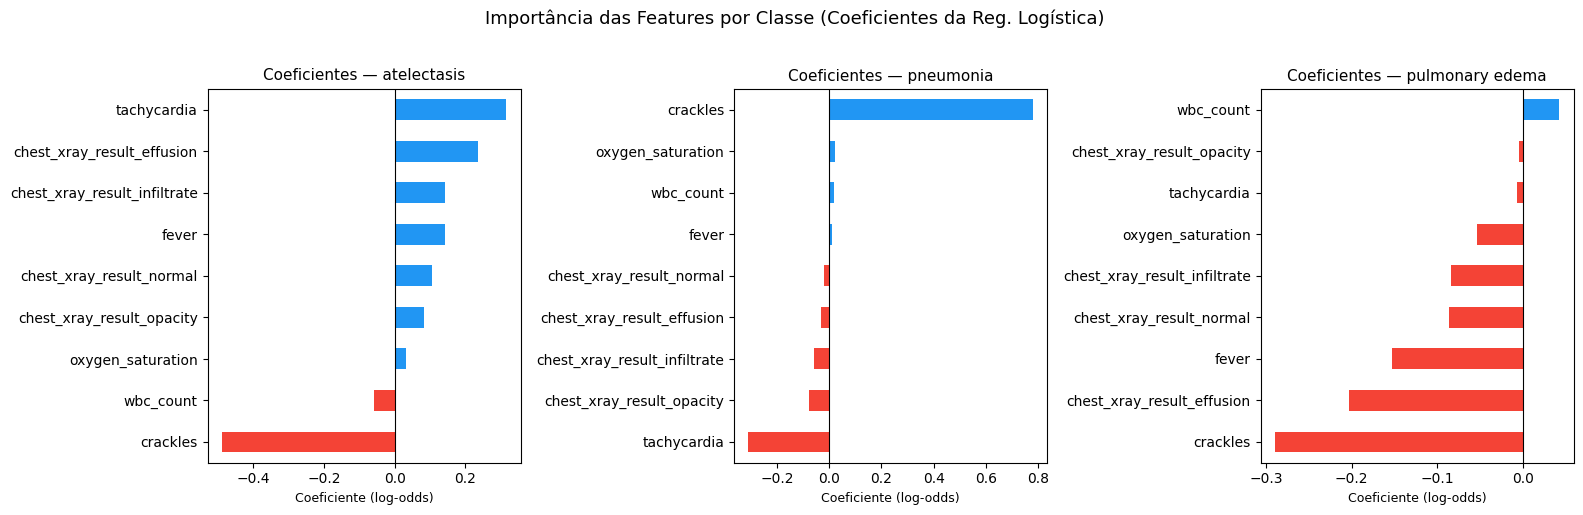

Salva em reports/feature_importance.png


In [7]:
# Para Regressão Logística multiclasse, os coeficientes indicam
# o peso de cada feature para cada classe (escala log-odds)
feature_names = X_test.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    coefs = pd.Series(modelo.coef_[i], index=feature_names)
    coefs_sorted = coefs.sort_values()
    cores_barras = ['#F44336' if v < 0 else '#2196F3' for v in coefs_sorted]
    coefs_sorted.plot(kind='barh', ax=ax, color=cores_barras)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes — {cls}', fontsize=11)
    ax.set_xlabel('Coeficiente (log-odds)', fontsize=9)

plt.suptitle('Importância das Features por Classe (Coeficientes da Reg. Logística)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/feature_importance.png')

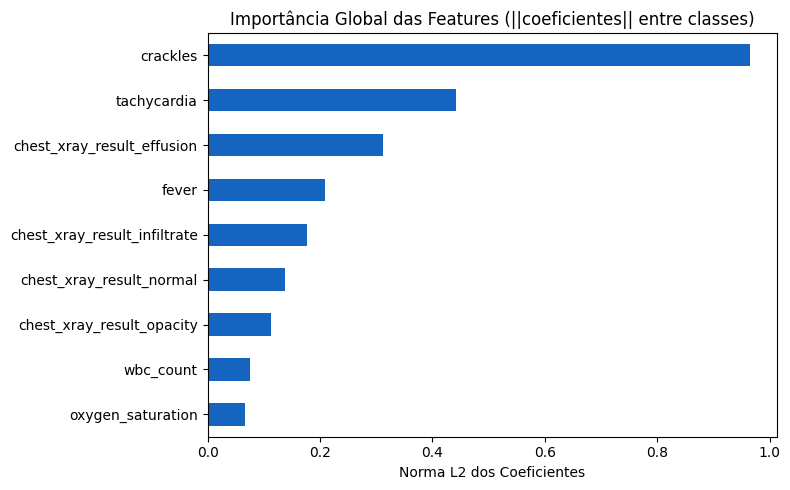

Ranking de importância global:
  crackles: 0.9645
  tachycardia: 0.4423
  chest_xray_result_effusion: 0.3122
  fever: 0.2088
  chest_xray_result_infiltrate: 0.1764
  chest_xray_result_normal: 0.1373
  chest_xray_result_opacity: 0.1128
  wbc_count: 0.0755
  oxygen_saturation: 0.0665


In [8]:
# Importância global — norma L2 dos coeficientes entre todas as classes
coef_global = np.linalg.norm(modelo.coef_, axis=0)
importancia_global = pd.Series(coef_global, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importancia_global.plot(kind='barh', ax=ax, color='#1565C0')
ax.set_title('Importância Global das Features (||coeficientes|| entre classes)', fontsize=12)
ax.set_xlabel('Norma L2 dos Coeficientes')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance_global.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ranking de importância global:')
for feat, val in importancia_global.items():
    print(f'  {feat}: {val:.4f}')

**Interpretação dos Coeficientes:**

- `crackles` (estertores pulmonares) é a feature mais importante globalmente — faz sentido clinicamente, pois crepitações são um sinal característico de várias doenças pulmonares.
- `tachycardia` (taquicardia) e `chest_xray_result_effusion` (derrame pleural no raio-X) também contribuem para a discriminação entre as classes.
- As features de raio-X (`effusion`, `infiltrate`, `opacity`, `normal`) deveriam, teoricamente, ser bastante discriminativas — o fato de não serem indica possível ruído ou inconsistência nos dados.

**Limitação do coeficiente como medida de importância:** Ao contrário do SHAP, os coeficientes da Regressão Logística são pesos globais e não capturam interações entre features. São interpretáveis em termos de log-odds, mas não respondem 'quanto essa feature contribuiu para esta predição específica'.

## 8. SHAP — Explicabilidade do Modelo

**O que é SHAP?**

SHAP (SHapley Additive exPlanations) é uma técnica de explicabilidade baseada na teoria dos jogos cooperativos. Ele calcula, para cada predição, a **contribuição marginal de cada feature** considerando todas as possíveis combinações de features — garantindo consistência e fidelidade matemática.

**Por que usar SHAP neste contexto?**
Em diagnóstico médico, não basta saber que o modelo previu 'pneumonia' — é preciso explicar *por que*. O SHAP permite que um médico entenda quais sinais clínicos influenciaram cada predição, tornando o modelo auditável e confiável.

In [9]:
# Para Regressão Logística, usar LinearExplainer (mais eficiente e correto que KernelExplainer)
explainer = shap.LinearExplainer(modelo, X_test_proc)
shap_values = explainer.shap_values(X_test_proc)

# shap_values shape: (n_amostras, n_features, n_classes)
print(f'shap_values shape: {shap_values.shape}')
print(f'expected_value (base value por classe): {explainer.expected_value}')

shap_values shape: (225, 9, 3)
expected_value (base value por classe): [-1.19100349 -1.21281478  2.40381827]


### 8.1 — SHAP Summary Plot Global (Importância média por classe)

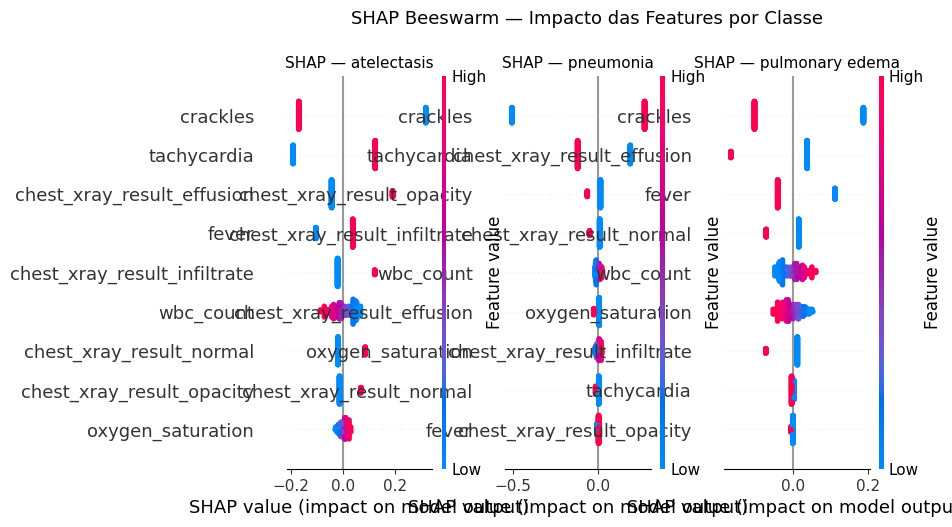

Salva em reports/shap_beeswarm.png


In [10]:
# Summary plot para cada classe — visualiza impacto e direção das features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cls in enumerate(le.classes_):
    plt.sca(axes[i])
    # Criar Explanation object por classe
    explanation_cls = shap.Explanation(
        values=shap_values[:, :, i],
        base_values=np.full(len(X_test_proc), explainer.expected_value[i]),
        data=X_test_proc.values,
        feature_names=X_test_proc.columns.tolist()
    )
    shap.plots.beeswarm(explanation_cls, max_display=9, show=False)
    plt.title(f'SHAP — {cls}', fontsize=11)

plt.suptitle('SHAP Beeswarm — Impacto das Features por Classe', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/shap_beeswarm.png')

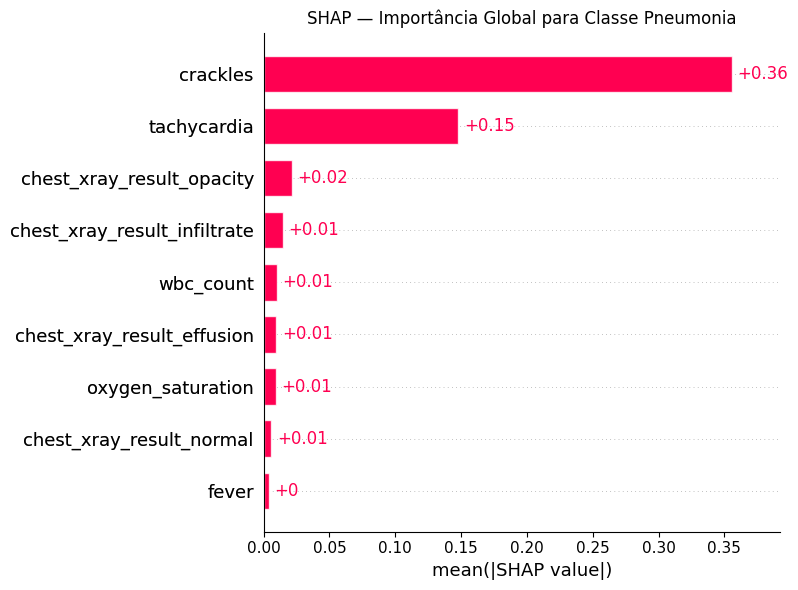

Salva em reports/shap_global.png


In [11]:
# Summary plot de barras — importância média absoluta por classe (foco em pneumonia)
explanation_pneumonia = shap.Explanation(
    values=shap_values[:, :, IDX_PNEUMONIA],
    base_values=np.full(len(X_test_proc), explainer.expected_value[IDX_PNEUMONIA]),
    data=X_test_proc.values,
    feature_names=X_test_proc.columns.tolist()
)

plt.figure(figsize=(8, 5))
shap.plots.bar(explanation_pneumonia, max_display=9, show=False)
plt.title('SHAP — Importância Global para Classe Pneumonia', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/shap_global.png')

**Interpretação do SHAP Global:**

- O SHAP confirma que `crackles` é a feature com maior influência nas predições de pneumonia — valores altos (presença de estertores) tendem a aumentar a probabilidade de classificação como pneumonia.
- `tachycardia` e `chest_xray_result_opacity` (opacidade no raio-X) também contribuem positivamente para a predição de pneumonia, o que é clinicamente coerente.
- `oxygen_saturation` com valores baixos (hipóxia) contribui positivamente — saturação baixa é um indicador importante de pneumonia grave.
- O SHAP revela a lógica interna do modelo: ele aprendeu padrões clinicamente plausíveis, mas não suficientes para discriminar com precisão entre as 3 condições.

### 8.2 — SHAP Waterfall — Explicação de uma Predição Individual

In [12]:
# Encontrar um caso real de pneumonia no conjunto de teste
indices_pneumonia = np.where(y_test == IDX_PNEUMONIA)[0]
idx = indices_pneumonia[0]  # primeiro caso real de pneumonia

print(f'Paciente #{idx}')
print(f'Diagnóstico real: {le.classes_[y_test[idx]]}')
print(f'Diagnóstico predito: {le.classes_[y_pred[idx]]}')
print(f'Probabilidades: {dict(zip(le.classes_, y_prob[idx].round(3)))}')
print()
print('Dados clínicos do paciente:')
display(X_test_proc.iloc[idx].to_frame('valor'))

Paciente #0
Diagnóstico real: pneumonia
Diagnóstico predito: pulmonary edema
Probabilidades: {'atelectasis': np.float64(0.026), 'pneumonia': np.float64(0.033), 'pulmonary edema': np.float64(0.942)}

Dados clínicos do paciente:


,valor
fever,1.000000
tachycardia,1.000000
crackles,1.000000
oxygen_saturation,-49.683796
wbc_count,-7.088182
chest_xray_result_effusion,0.000000
chest_xray_result_infiltrate,0.000000
chest_xray_result_normal,0.000000
chest_xray_result_opacity,0.000000


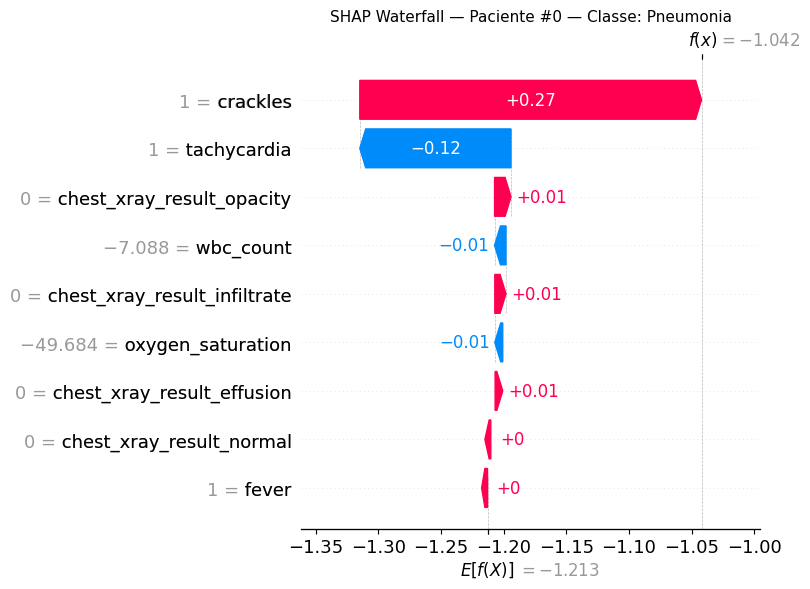

Salva em reports/shap_waterfall_pneumonia.png


In [13]:
# Waterfall para a classe PNEUMONIA (índice 1)
# Mostra como cada feature puxou a predição para cima ou para baixo
waterfall_exp = shap.Explanation(
    values=shap_values[idx, :, IDX_PNEUMONIA],
    base_values=explainer.expected_value[IDX_PNEUMONIA],
    data=X_test_proc.iloc[idx].values,
    feature_names=X_test_proc.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(waterfall_exp, show=False)
plt.title(f'SHAP Waterfall — Paciente #{idx} — Classe: Pneumonia', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/shap_waterfall_pneumonia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/shap_waterfall_pneumonia.png')

**Como ler o Waterfall Plot:**

O gráfico parte do `E[f(x)]` (valor esperado base — predição média do modelo na ausência de informação) e mostra como cada feature desloca a predição para cima (azul = aumenta probabilidade de pneumonia) ou para baixo (vermelho = reduz). O valor final é a predição para este paciente específico.

Este tipo de visualização é essencial em contexto médico: permite ao profissional de saúde entender *por que* o modelo chegou a determinada conclusão, identificar se a lógica faz sentido clínico, e decidir se deve ou não considerar a sugestão do modelo.

### 8.3 — SHAP Force Plot — Visão Alternativa da Predição Individual

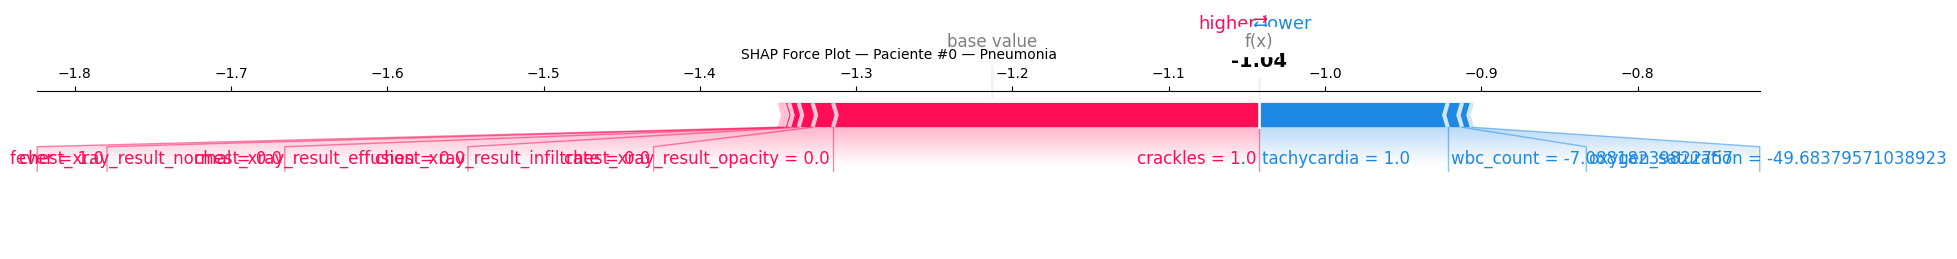

Salva em reports/shap_force_plot.png


In [14]:
# Force plot para o mesmo paciente — visualização horizontal das contribuições
shap.initjs()
force_plot = shap.force_plot(
    base_value=explainer.expected_value[IDX_PNEUMONIA],
    shap_values=shap_values[idx, :, IDX_PNEUMONIA],
    features=X_test_proc.iloc[idx],
    feature_names=X_test_proc.columns.tolist(),
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — Paciente #{idx} — Pneumonia', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salva em reports/shap_force_plot.png')

## 9. Resumo dos Resultados

In [15]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

resultados = {
    'Modelo': meta['nome'],
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
    'Precision Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
    'F1 Macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
    'AUC Pneumonia': auc(*roc_curve(label_binarize(y_test, classes=[0,1,2])[:,1], y_prob[:,1])[:2]),
}

print('=== RESUMO FINAL DAS MÉTRICAS ===')
for k, v in resultados.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

=== RESUMO FINAL DAS MÉTRICAS ===
  Modelo: Reg. Logística (tuned)
  Accuracy: 0.3333
  Recall Macro: 0.3333
  Precision Macro: 0.1111
  F1 Macro: 0.1667
  AUC Pneumonia: 0.6260


## 10. Discussão Crítica — Uso Prático do Modelo

### Por que usar Recall em vez de Accuracy?

Em diagnóstico médico, os erros **não são simétricos**. Existem dois tipos de erros:

| Erro | Diagnóstico | Consequência |
|---|---|---|
| **Falso Negativo** | Paciente com pneumonia classificado como saudável | Paciente vai para casa sem tratamento → pode evoluir para sepse, óbito |
| **Falso Positivo** | Paciente saudável classificado como doente | Exames adicionais desnecessários → custo e estresse, mas tratável |

O **Recall** (sensibilidade) mede a taxa de Falsos Negativos: `Recall = TP / (TP + FN)`. Um Recall alto significa que o modelo encontra a maioria dos casos reais. A **Accuracy** esconde o problema em datasets desbalanceados — um modelo que prevê sempre 'sem doença' pode ter accuracy alta mas Recall = 0%.

Por isso, o critério de seleção do modelo no Step 5 foi **Recall macro** (média do Recall entre as 3 classes).

### O modelo pode ser usado na prática?

**Não, nas condições atuais.** Os resultados obtidos mostram que o modelo não possui poder discriminativo suficiente:

1. **Accuracy de 33%** — equivale a escolher aleatoriamente entre 3 classes. Nenhum valor clínico.
2. **Recall de pneumonia = 0** — o modelo falha completamente em detectar pneumonia. Em triagem clínica, isso é inaceitável.
3. **AUC próximo de 0.5** — confirma que as probabilidades do modelo não são melhores que o acaso.

### Limitações identificadas

1. **Features insuficientes:** O dataset clínico possui apenas 9 features binárias e numéricas. Diagnóstico real envolve dezenas de variáveis (história clínica completa, exames laboratoriais detalhados, cultura de escarro, etc.).

2. **Sobreposição de sintomas:** Atelectasia, pneumonia e edema pulmonar compartilham sintomas similares (dispneia, hipóxia, crepitações). Com features tão limitadas, a separação entre as 3 classes é inerentemente difícil.

3. **Qualidade e tamanho do dataset:** Com datasets maiores e mais ricos em features, algoritmos mais poderosos (Random Forest, Gradient Boosting, Redes Neurais) podem capturar padrões não-lineares que a Regressão Logística não captura.

4. **Seleção do modelo:** O Random Forest, que geralmente supera a Regressão Logística em datasets com interações entre features, deveria ser avaliado mais rigorosamente como candidato final.

### Como o modelo deveria ser usado pelo profissional de saúde

Mesmo um modelo com melhor desempenho **nunca substituiria o médico** — seria uma ferramenta de **triagem e suporte**:

- **Triagem inicial:** Identificar pacientes de alto risco para priorização no atendimento.
- **Segunda opinião:** Alertar o médico para possíveis diagnósticos que poderiam ser negligenciados.
- **Auditoria:** O médico examina os SHAP values para entender o raciocínio do modelo e decidir se concorda.
- **Decisão final sempre humana:** O profissional é o responsável legal e ético pelo diagnóstico.

Para validação clínica real, o modelo precisaria passar por estudos prospectivos em populações reais, validação por especialistas, aprovação regulatória (ANVISA no Brasil, FDA nos EUA) e testes de viés em subpopulações.

### O que o SHAP revelou

Apesar do desempenho ruim do modelo, o SHAP revelou que a lógica interna é **clinicamente coerente**:
- **Crackles** (estertores) é a feature mais importante — crepitações são um sinal auscultatório clássico em pneumonia e edema pulmonar.
- **Tachycardia** e **baixa saturação de oxigênio** contribuem para diagnósticos de doença pulmonar — fazem sentido fisiopatológico.
- **Opacidade no raio-X** favorece pneumonia — hallmark radiológico da doença.

Isso sugere que o modelo aprendeu padrões clínicos reais, mas que o dataset não possui informação suficiente para discriminar com precisão entre as 3 condições. O problema é de **dados insuficientes**, não de aprendizado incorreto.

## 11. Checklist da Etapa 2.7

- [x] `07_avaliacao_shap.ipynb` criado e executado sem erros
- [x] Avaliação feita com o **modelo tuned** no conjunto de **teste** (nunca visto antes)
- [x] Métricas: accuracy, precision, recall, F1-score documentadas
- [x] Curva ROC gerada, AUC calculado e salvo em `reports/`
- [x] Feature Importance plotada e salva
- [x] SHAP summary plot (global) gerado e salvo em `reports/`
- [x] SHAP waterfall de pelo menos 1 predição individual
- [x] Texto discutindo: escolha da métrica, limitações, uso prático, papel do médico